Bharti Kunjir

Exploratory Data Analysis – School Dataset Day 1 Task | Data Science

Importing Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

Data Understanding

In [2]:
df = pd.read_excel('School data.xlsx')
print(f'Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns')

Dataset Shape: 5200 rows × 17 columns


In [3]:
df.head()

,School_ID,District,Block,Urban_Rural,%_Math_Score,%_Language_Score,%_Science_Score,Teacher_Student_Ratio,Avg_Teacher_Experience_Years,Teacher_Trainings_Attended,Electricity_Available,Internet_Available,Functional_Toilets,Library_Available,%_Marginalized_Students,%_Students_With_Home_Internet,Parent_Literacy_Rate
0,SCH_1,District_C,Block_C1,Rural,43.32,48.87,48.89,40.1,5.7,1,1,0.0,1,0,29.7,5.7,33.9
1,SCH_2,District_A,Block_A3,Rural,81.98,83.18,83.26,NaN,5.8,1,1,0.0,0,0,36.1,4.0,40.6
2,SCH_3,District_B,Block_B1,Rural,44.68,46.38,40.19,29.9,7.1,2,1,1.0,0,0,38.9,17.4,47.6
3,SCH_4,District_A,Block_A1,Urban,44.86,35.20,47.77,24.6,2.6,1,1,1.0,0,0,11.2,35.8,73.3
4,SCH_5,District_C,Block_C1,Rural,47.41,47.94,50.99,39.8,6.1,1,1,0.0,1,0,33.1,13.6,35.3


In [5]:
print('Column Info')
df.info()

Column Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5200 entries, 0 to 5199
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   School_ID                      5200 non-null   object 
 1   District                       5200 non-null   object 
 2   Block                          5200 non-null   object 
 3   Urban_Rural                    5200 non-null   object 
 4   %_Math_Score                   4942 non-null   float64
 5   %_Language_Score               5200 non-null   float64
 6   %_Science_Score                5200 non-null   float64
 7   Teacher_Student_Ratio          4940 non-null   float64
 8   Avg_Teacher_Experience_Years   5200 non-null   float64
 9   Teacher_Trainings_Attended     5200 non-null   int64  
 10  Electricity_Available          5200 non-null   int64  
 11  Internet_Available             4940 non-null   float64
 12  Functional_Toilets             5200 

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
%_Math_Score,4942.0,60.055898,15.106160,0.326857,49.5825,59.85,70.6300,107.344878
%_Language_Score,5200.0,62.970896,16.569802,1.380000,51.5200,63.03,74.4525,100.000000
%_Science_Score,5200.0,61.338762,18.025438,1.510000,48.8900,61.15,73.9500,100.000000
Teacher_Student_Ratio,4940.0,29.980951,9.957824,1.000000,23.1000,29.80,36.6000,100.000000
Avg_Teacher_Experience_Years,5200.0,8.096596,3.916906,0.000000,5.4000,8.00,10.8000,22.700000
Teacher_Trainings_Attended,5200.0,1.995385,1.430434,0.000000,1.0000,2.00,3.0000,9.000000
Electricity_Available,5200.0,0.895577,0.305838,0.000000,1.0000,1.00,1.0000,1.000000
Internet_Available,4940.0,0.295344,0.456243,0.000000,0.0000,0.00,1.0000,1.000000
Functional_Toilets,5200.0,0.954423,0.208586,0.000000,1.0000,1.00,1.0000,1.000000
Library_Available,5200.0,0.483462,0.499774,0.000000,0.0000,0.00,1.0000,1.000000


In [7]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print('Categorical columns:', cat_cols)
for col in cat_cols:
    print(f'\n--- {col} ---')
    print(df[col].value_counts())

Categorical columns: ['School_ID', 'District', 'Block', 'Urban_Rural']

--- School_ID ---
School_ID
SCH_5184    1
SCH_5183    1
SCH_5182    1
SCH_5181    1
SCH_5180    1
           ..
SCH_5       1
SCH_4       1
SCH_3       1
SCH_2       1
SCH_1       1
Name: count, Length: 5200, dtype: int64

--- District ---
District
District_C    1810
District_A    1699
District_B    1691
Name: count, dtype: int64

--- Block ---
Block
Block_C3    622
Block_C2    595
Block_A2    594
Block_C1    593
Block_B2    590
Block_B3    574
Block_A1    557
Block_A3    548
Block_B1    527
Name: count, dtype: int64

--- Urban_Rural ---
Urban_Rural
Rural    3579
Urban    1621
Name: count, dtype: int64


Data Cleaning

In [8]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
School_ID                          0
District                           0
Block                              0
Urban_Rural                        0
%_Math_Score                     258
%_Language_Score                   0
%_Science_Score                    0
Teacher_Student_Ratio            260
Avg_Teacher_Experience_Years       0
Teacher_Trainings_Attended         0
Electricity_Available              0
Internet_Available               260
Functional_Toilets                 0
Library_Available                  0
%_Marginalized_Students            0
%_Students_With_Home_Internet      0
Parent_Literacy_Rate             259
dtype: int64


In [9]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df[missing_df['Missing Count'] > 0]

,Missing Count,Missing %
%_Math_Score,258,4.96
Teacher_Student_Ratio,260,5.00
Internet_Available,260,5.00
Parent_Literacy_Rate,259,4.98


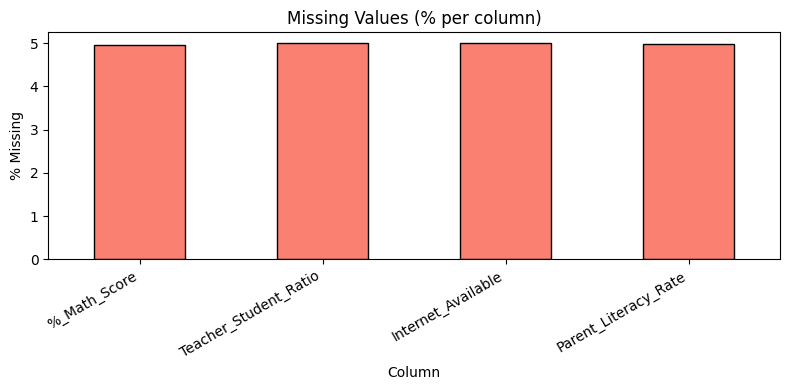

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
missing_pct[missing_pct > 0].plot(kind='bar', color='salmon', edgecolor='black', ax=ax)
ax.set_title('Missing Values (% per column)')
ax.set_ylabel('% Missing')
ax.set_xlabel('Column')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [12]:
dupes = df.duplicated().sum()
print(f'Duplicate rows found: {dupes}')

if dupes > 0:
    df.drop_duplicates(inplace=True)
    print(f'Duplicates removed. New shape: {df.shape}')
else:
    print('No duplicates — dataset is clean')

Duplicate rows found: 0
No duplicates — dataset is clean


In [13]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()

print('Outlier counts per column (IQR method):')
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    if outliers > 0:
        print(f'  {col}: {outliers} outliers')

Outlier counts per column (IQR method):
  %_Math_Score: 53 outliers
  %_Language_Score: 12 outliers
  %_Science_Score: 8 outliers
  Teacher_Student_Ratio: 32 outliers
  Avg_Teacher_Experience_Years: 12 outliers
  Teacher_Trainings_Attended: 32 outliers
  Electricity_Available: 543 outliers
  Functional_Toilets: 237 outliers
  %_Marginalized_Students: 4 outliers
  %_Students_With_Home_Internet: 17 outliers
  Parent_Literacy_Rate: 53 outliers


Statistics

In [14]:
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
       %_Math_Score  %_Language_Score  %_Science_Score  Teacher_Student_Ratio  \
count   5200.000000       5200.000000      5200.000000            5200.000000   
mean      60.045682         62.970896        61.338762              29.971904   
std       14.726637         16.569802        18.025438               9.705717   
min        0.326857          1.380000         1.510000               1.000000   
25%       50.197500         51.520000        48.890000              23.400000   
50%       59.850000         63.030000        61.150000              29.800000   
75%       69.972500         74.452500        73.950000              36.125000   
max      107.344878        100.000000       100.000000             100.000000   

       Avg_Teacher_Experience_Years  Teacher_Trainings_Attended  \
count                   5200.000000                 5200.000000   
mean                       8.096596                    1.995385   
std                        3.916906            

Univariate Analysis

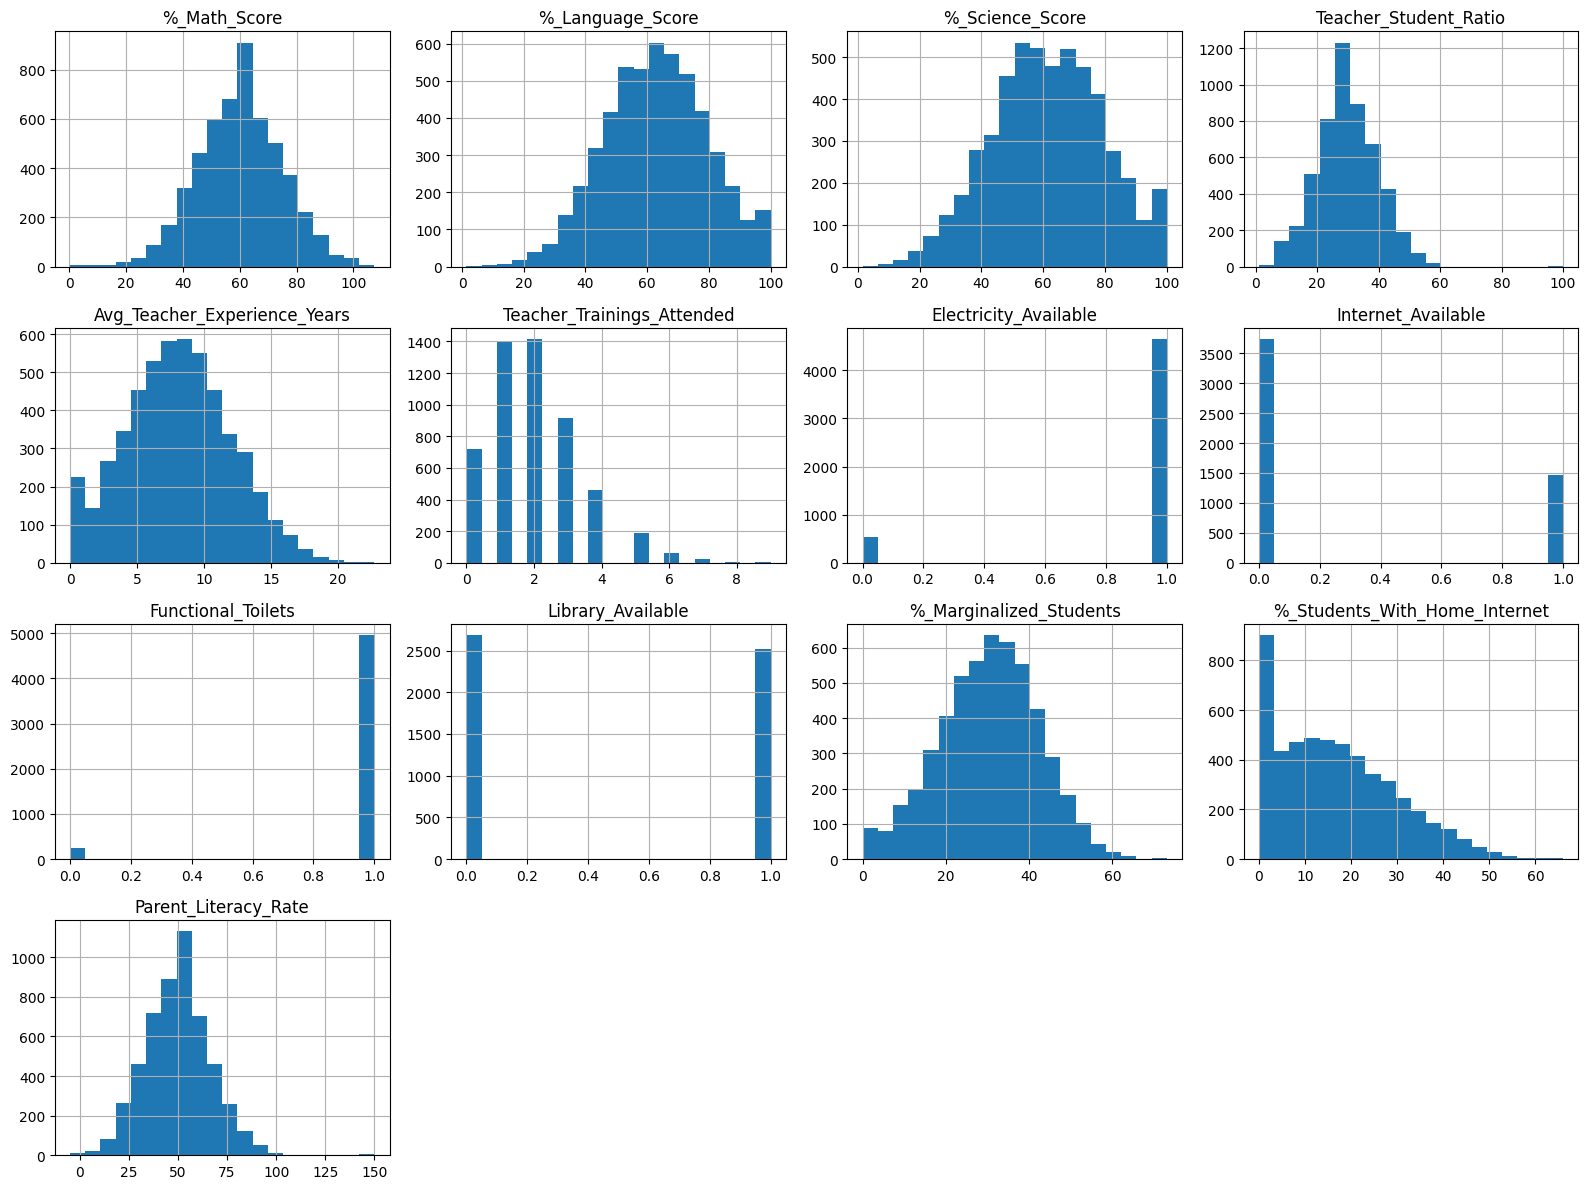

In [17]:
df.hist(figsize=(16,12), bins=20)
plt.tight_layout()
plt.show()

Bivariate Analysis

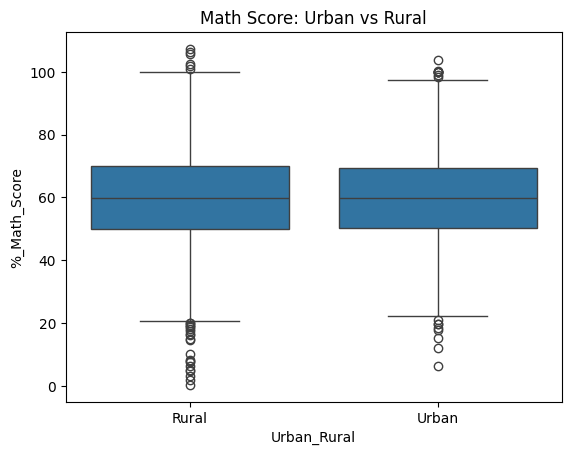

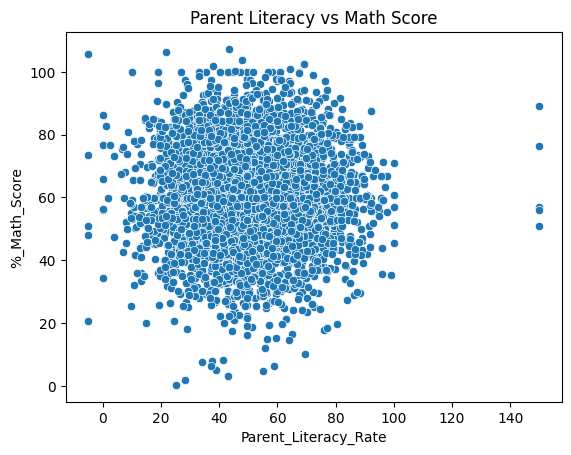

In [18]:
if 'Urban_Rural' in df.columns and '%_Math_Score' in df.columns:
    sns.boxplot(x='Urban_Rural', y='%_Math_Score', data=df)
    plt.title("Math Score: Urban vs Rural")
    plt.show()

if 'Parent_Literacy_Rate' in df.columns and '%_Math_Score' in df.columns:
    sns.scatterplot(x='Parent_Literacy_Rate', y='%_Math_Score', data=df)
    plt.title("Parent Literacy vs Math Score")
    plt.show()


Correlation Analysis

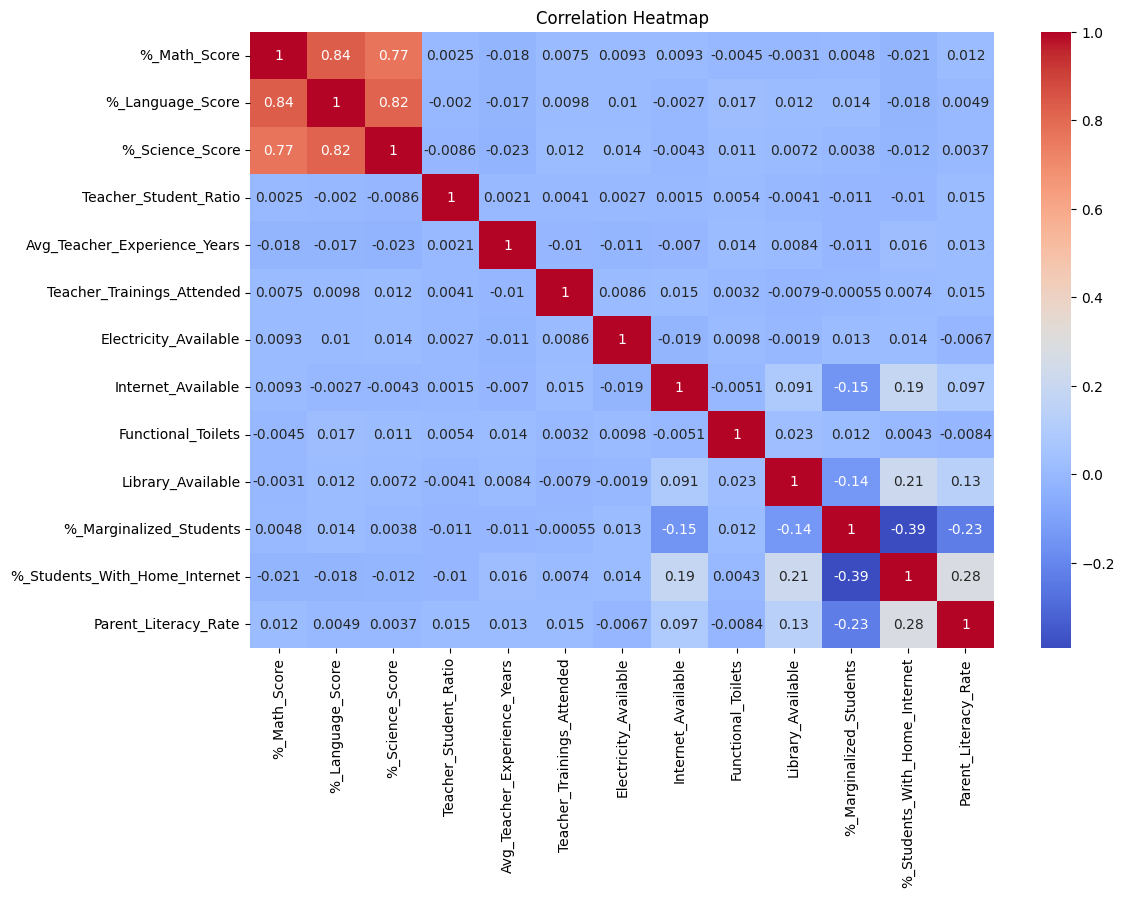

In [19]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Feature Engineering

In [21]:
if '%_Math_Score' in df.columns and '%_Language_Score' in df.columns and '%_Science_Score' in df.columns:
    df['Overall_Score'] = (
        df['%_Math_Score'] +
        df['%_Language_Score'] +
        df['%_Science_Score']
    ) / 3

    print("\nOverall Score Created Successfully")


Overall Score Created Successfully


Top Performing Schools

In [22]:
if 'School_ID' in df.columns and 'Overall_Score' in df.columns:
    top5 = df[['School_ID', 'Overall_Score']].sort_values(
        by='Overall_Score',
        ascending=False
    ).head(5)

    print("\nTop 5 Schools:")
    print(top5)


Top 5 Schools:
     School_ID  Overall_Score
1263  SCH_1264          100.0
1348  SCH_1349          100.0
4500  SCH_4501          100.0
4782  SCH_4783          100.0
650    SCH_651          100.0


Insights

In [23]:
print("\nInsights:")
print("1. Scores in Math, Language, Science are positively related.")
print("2. Parent literacy affects student performance.")
print("3. Internet access helps learning.")
print("4. Some schools need better teacher allocation.")
print("5. Urban and rural performance is nearly similar.")


Insights:
1. Scores in Math, Language, Science are positively related.
2. Parent literacy affects student performance.
3. Internet access helps learning.
4. Some schools need better teacher allocation.
5. Urban and rural performance is nearly similar.
